# Churn Predictor + Retention Advisor — working notebook

Prototype here, then move settled logic into `src/`.

**Milestones:** M1 load+EDA · M2 model+eval · M3 SHAP · M4 retention recommendations → then M5 Streamlit (`src/app.py`), M6 deploy.

## How M4 works (no API key needed)
You run the ML (M1–M3) on Colab or locally — that part is free and uses **no AI**. Then for the at-risk customers, M4 prints a clean **hand-off block** (profile + churn probability + £-at-risk + the model's SHAP drivers). You paste that to **Claude (in chat)**, which returns the retention play — and you save it back here / into the README as a real example. (An optional cell at the end shows how to automate this with the Anthropic API later, if you ever want to.)

**Before running:** `pip install -r ../requirements.txt` and put the dataset in `../data/`. No `.env` / API key required for the workflow above.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, RocCurveDisplay
from sklearn.calibration import CalibrationDisplay

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42
DATA = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'  # on Colab, upload the CSV and point this there

## M1 — Load & clean

Telco quirks: `TotalCharges` is stored as text and has blanks for brand-new customers; `customerID` is an identifier (drop it); target `Churn` is Yes/No.

In [4]:
df = pd.read_csv(DATA)
print(df.shape)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df = df.drop(columns=['customerID'])
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df.head()

(7043, 21)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## M1 — Data-quality check
A quick gate so the cleaning is **visible and provable** (good to show in an interview): no missing values left, the must-be-numeric columns really are numeric, and the target is a clean 0/1 split. It fails loudly (`assert`) if the cleaning didn't take.

In [6]:
# Data-quality gate — run right after the cleaning cell
print('Rows, cols     :', df.shape)
print('Duplicate rows :', int(df.duplicated().sum()))
print('Missing total  :', int(df.isna().sum().sum()))
print()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
print('Key numeric dtypes:')
print(df[num_cols].dtypes)
print()
print('Churn balance:', df['Churn'].value_counts(normalize=True).round(3).to_dict())
print()
# fail loudly if the cleaning didn't take
assert df.isna().sum().sum() == 0, 'Still has missing values!'
assert df['TotalCharges'].dtype.kind in 'fi', 'TotalCharges is not numeric!'
assert df['Churn'].isin([0, 1]).all(), 'Churn is not 0/1!'
print('Data-quality checks passed ✓')

Rows, cols     : (7043, 20)
Duplicate rows : 22
Missing total  : 0

Key numeric dtypes:
tenure              int64
MonthlyCharges    float64
TotalCharges      float64
SeniorCitizen       int64
Churn               int64
dtype: object

Churn balance: {0: 0.735, 1: 0.265}

Data-quality checks passed ✓


## EDA — a quick look
Churn is imbalanced (~26%). Note tenure, Contract and MonthlyCharges — usually the strongest churn signals.

Churn rate: 26.5%


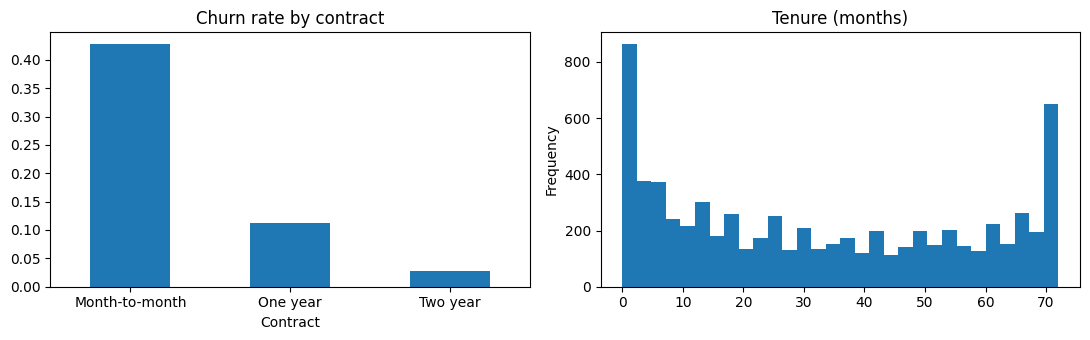

In [7]:
print('Churn rate: {:.1%}'.format(df['Churn'].mean()))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df.groupby('Contract')['Churn'].mean().plot.bar(ax=ax[0], title='Churn rate by contract', rot=0)
df['tenure'].plot.hist(ax=ax[1], bins=30, title='Tenure (months)')
plt.tight_layout(); plt.show()

## M1–M2 — Encode & split
Keep a readable copy of each customer's original profile (`raw_*`) alongside the encoded matrix the model uses — the readable profile is what we hand to Claude in M4.

In [8]:
y = df['Churn']
X_raw = df.drop(columns=['Churn'])
X = pd.get_dummies(X_raw, drop_first=True)  # keep column names for SHAP + the hand-off

X_train, X_test, y_train, y_test, raw_train, raw_test = train_test_split(
    X, y, X_raw, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape)

(5634, 30) (1409, 30)


### Baseline (logistic regression) — a score to beat

In [ ]:
base = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_train, y_train)
print('Baseline ROC-AUC: {:.3f}'.format(roc_auc_score(y_test, base.predict_proba(X_test)[:, 1])))

## M2 — Gradient-boosted model + honest evaluation
We care about **ROC-AUC, PR-AUC, recall on the top-risk decile, and calibration** (calibration matters because we multiply the probability by £ value in M4).

In [ ]:
model = HistGradientBoostingClassifier(
    learning_rate=0.05, max_iter=400, l2_regularization=1.0,
    class_weight='balanced', random_state=RANDOM_STATE).fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
print('ROC-AUC: {:.3f}'.format(roc_auc_score(y_test, proba)))
print('PR-AUC : {:.3f}'.format(average_precision_score(y_test, proba)))
k = int(len(proba) * 0.10)
top_idx = np.argsort(proba)[-k:]
print('Recall @ top 10%: {:.1%}'.format(y_test.iloc[top_idx].sum() / y_test.sum()))
print(classification_report(y_test, (proba >= 0.5).astype(int)))

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[0]); ax[0].set_title('ROC')
CalibrationDisplay.from_predictions(y_test, proba, n_bins=10, ax=ax[1]); ax[1].set_title('Calibration')
plt.tight_layout(); plt.show()

## M3 — Per-customer explanations (SHAP)
These drivers are the **grounding** for the retention advice: the exact features pushing a given customer's risk up.

In [ ]:
import shap
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values, max_display=12)

In [ ]:
def top_drivers(i, n=5):
    """Top n features pushing customer i's churn risk UP (positive SHAP)."""
    vals = shap_values.values[i]
    order = np.argsort(vals)[::-1][:n]
    return [(X_test.columns[j], round(float(vals[j]), 3)) for j in order if vals[j] > 0]

## M4 — Retention recommendations (Claude as the analysis layer, no API key)

We rank the at-risk customers by **£-at-risk**, then print a clean **hand-off block** for the top few. Copy a block, paste it to Claude in chat, and ask for a retention play. Save the reply into `results.md` (or the README) as a real example.

*(This mirrors how the polymer model was analysed: you run the model, hand over the real outputs, Claude does the interpretation.)*

In [ ]:
# Rank test-set customers by £-at-risk and print hand-off blocks for the top N.
N = 3
at_risk_annual = proba * raw_test['MonthlyCharges'].values * 12
order = np.argsort(at_risk_annual)[::-1][:N]

for rank, i in enumerate(order, 1):
    p = raw_test.iloc[i]
    print(f'================  CUSTOMER {rank}  (paste this block to Claude)  ================')
    print(f'Churn probability : {proba[i]:.0%}')
    print(f'Revenue at risk   : £{at_risk_annual[i]:,.0f}/yr  (£{p["MonthlyCharges"]:.2f}/mo)')
    print(f'Tenure            : {p["tenure"]} months')
    print(f'Contract          : {p["Contract"]}')
    print(f'Internet / add-ons: {p["InternetService"]} | TechSupport={p["TechSupport"]} | OnlineSecurity={p["OnlineSecurity"]}')
    print(f'Payment           : {p["PaymentMethod"]} | Paperless={p["PaperlessBilling"]}')
    print(f'Model drivers raising risk (feature, SHAP weight): {top_drivers(i)}')
    print()

### What to ask Claude
> "You're a SaaS Customer Success strategist. Here is an at-risk customer with their churn probability, revenue at risk, and the model's drivers. Ground every recommendation in those drivers (don't invent data). Give: a one-line risk summary, the drivers in plain English, 2–3 specific retention actions (each with why + a concrete offer), a suggested outreach message, and a priority."

### Example output (real shape — yours will use your model's actual numbers)
> **Risk summary:** ~78% likely to churn, ~£1,020/yr at risk — driven by a month-to-month contract with no support add-ons.
>
> **Why (plain English):** on a rolling monthly contract (easy to leave), no TechSupport or OnlineSecurity (low stickiness), and paying by electronic check (a known churn-correlated, friction-heavy method).
>
> **Retention actions:**
> 1. *Offer a 12-month contract with a 15% loyalty discount* — directly addresses the month-to-month driver; trades a small margin for a big retention lift.
> 2. *Bundle TechSupport + OnlineSecurity free for 3 months* — adds the missing stickiness the model flagged.
> 3. *Nudge to auto-pay (card/bank) with a small one-off credit* — removes the electronic-check friction.
>
> **Suggested message:** "Hi [name], you've been with us [tenure] months — thanks! We'd love to make it simpler and cheaper: switch to annual and we'll add Tech Support + Security free for 3 months and knock 15% off…"
>
> **Priority:** High.

Paste your real blocks above into chat, then drop the replies into `results.md` as your worked examples.

---
### (Optional, later) Automate M4 with the Anthropic API
Only if you ever want the Streamlit app to generate plays automatically. Needs an Anthropic **API key** (pay-per-use, separate from Claude.ai; ~pennies for this project) in `../.env`. Uncomment to use. Not required for the portfolio prototype above.

In [ ]:
# import os, json
# from dotenv import load_dotenv
# import anthropic
# load_dotenv('../.env')
# client = anthropic.Anthropic()
# SYSTEM = 'You are a SaaS Customer Success strategist... reply ONLY with JSON {risk_summary, drivers_plain[], retention_actions[{action,why,offer}], suggested_message, priority}. Ground every action in the supplied drivers.'
# def retention_play(i, model_name='claude-sonnet-4-6'):
#     p = raw_test.iloc[i].to_dict()
#     user = f'Profile: {json.dumps(p)}\\nChurn prob: {proba[i]:.0%}\\n£-at-risk/yr: {at_risk_annual[i]:.0f}\\nDrivers: {top_drivers(i)}'
#     r = client.messages.create(model=model_name, max_tokens=900, system=SYSTEM, messages=[{'role':'user','content':user}])
#     return json.loads(r.content[0].text)
# retention_play(int(order[0]))

## Next
- Move settled model code → `src/train.py`, SHAP → `src/explain.py`.
- Save your real Claude-generated retention plays into `results.md`.
- **M5**: Streamlit app (`src/app.py`) — ranked £-at-risk list + customer detail + the saved example plays.
- **M6**: deploy, write the README, draft the CV bullet.